# Notebook 05e — Smoothing Sensitivity for Low-R² m=1 Neurons

Tests Tony's two-stage smoothing proposal on the ambiguous subset:
R²<0.5 AND m_final==1 from the nb05d v2 manually-reviewed population.

**Three sigma values tested per neuron:**
- σ=0.75 (current default)
- σ=1.0 (stage-2 refit on σ=0.75)
- σ=1.5 (stage-2 refit on σ=0.75)

**Display:** Raw RF | σ=0.75 m=1 | σ=1.0 stage-2 m=1 | σ=1.5 stage-2 m=1 | σ=0.75 m=0 reference

**Output:** `outputs/rf_params/order_full_v2/smoothing_review_judgements.csv`

In [1]:
import sys, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    fit_rf_by_order,
    _build_design_matrix, _pixel_size, _LAMBDA_GRID,
    gaussian_deriv_m0, gaussian_deriv_m1, gaussian_deriv_m2,
)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('Imports OK')

Imports OK


In [2]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
base_dir  = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir = base_dir / 'data' / 'cache'
lists_dir = base_dir / 'data' / 'experiment_lists'
nb05d_dir = base_dir / 'outputs' / 'rf_params' / 'order_full_v2'

FINAL_CSV     = nb05d_dir / 'rf_params_order_v2_all_containers.csv'
JUDGEMENT_CSV = nb05d_dir / 'smoothing_review_judgements.csv'

boc = BrainObservatoryCache(manifest_file=str(cache_dir / 'manifest.json'))

batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))
print(f'Containers: {len(container_to_exp)}')

Containers: 17


In [3]:
# ---------------------------------------------------------------------------
# Load final population, rebuild m_final, filter to ambiguous m=1 subset
# ---------------------------------------------------------------------------
all_df = pd.read_csv(FINAL_CSV)

nb07_j = base_dir / 'outputs' / 'rf_params' / 'order_full'  / 'manual_m_judgements.csv'
nb09_j = base_dir / 'outputs' / 'rf_params' / 'nb09' / 'nb09_review_judgements.csv'

judged = {}
for path, label in [(nb07_j, 'nb07'), (nb09_j, 'nb09')]:
    if path.exists():
        jdf = pd.read_csv(path)
        jdf = jdf[jdf['m_manual'] >= 0]
        for _, r in jdf.iterrows():
            judged[int(r['cell_id'])] = int(r['m_manual'])
        print(f'Loaded {len(jdf)} judgements from {label}')

all_df['m_manual'] = all_df['cell_id'].map(judged)
all_df['m_final']  = np.where(
    all_df['m_manual'].notna(), all_df['m_manual'], all_df['derivative_order']
).astype(int)

# Target: confirmed m=1 but low R²
candidates = (
    all_df[(all_df['m_final'] == 1) & (all_df['r_squared'] < 0.5)]
    .sort_values('r_squared', ascending=False)
    .reset_index(drop=True)
    .copy()
)
print(f'\nTotal m=1 neurons: {(all_df["m_final"]==1).sum()}')
print(f'm=1 with R²<0.5 (target): {len(candidates)}')
print(f'R² range: {candidates["r_squared"].min():.3f}–{candidates["r_squared"].max():.3f}')

Loaded 225 judgements from nb07
Loaded 112 judgements from nb09

Total m=1 neurons: 84
m=1 with R²<0.5 (target): 63
R² range: 0.303–0.495


In [4]:
# ---------------------------------------------------------------------------
# batch_get_rf_maps_safe — identical to nb05d
# ---------------------------------------------------------------------------
def batch_get_rf_maps_safe(dataset, requested_ids,
                            n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found.')
    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if not stim_name:
        raise ValueError('No sparse noise stimulus.')
    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix_size        = _pixel_size(stim_name)
    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)
    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape
    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)
    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)
    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few presentations.')
    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)
    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix_size)
    return rf_out

print('batch_get_rf_maps_safe defined')

batch_get_rf_maps_safe defined


In [5]:
# ---------------------------------------------------------------------------
# Load RF maps for candidates — one container at a time with progress
# ---------------------------------------------------------------------------
rf_map_cache  = {}
dataset_cache = {}

by_container = candidates.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Loading {len(candidates)} neurons across {len(by_container)} containers')

t_start = time.time()
for i, (container_id, cids) in enumerate(by_container.items()):
    if container_id not in container_to_exp:
        print(f'  [{i+1}/{len(by_container)}] {container_id}: not in session_c — skip')
        continue
    print(f'  [{i+1}/{len(by_container)}] Container {container_id} '
          f'({len(cids)} neurons) ...', end=' ', flush=True)
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(
                container_to_exp[container_id])
        maps = batch_get_rf_maps_safe(dataset_cache[container_id], cids)
        rf_map_cache.update(maps)
        print(f'{len(maps)} loaded  ({time.time()-t_start:.0f}s elapsed)')
    except Exception as e:
        print(f'FAIL — {e}')

review_df = candidates[candidates['cell_id'].isin(rf_map_cache)].reset_index(drop=True)
print(f'\n{len(review_df)} neurons ready for review')

Loading 63 neurons across 15 containers
  [1/15] Container 511507650 (2 neurons) ... 2 loaded  (66s elapsed)
  [2/15] Container 511509529 (3 neurons) ... 3 loaded  (135s elapsed)
  [3/15] Container 511510670 (3 neurons) ... 3 loaded  (208s elapsed)
  [4/15] Container 511510718 (5 neurons) ... 5 loaded  (287s elapsed)
  [5/15] Container 511510855 (8 neurons) ... 8 loaded  (366s elapsed)
  [6/15] Container 650389885 (2 neurons) ... 2 loaded  (438s elapsed)
  [7/15] Container 652842570 (5 neurons) ... 5 loaded  (503s elapsed)
  [8/15] Container 653125128 (7 neurons) ... 7 loaded  (569s elapsed)
  [9/15] Container 661437138 (1 neurons) ... 1 loaded  (645s elapsed)
  [10/15] Container 661732156 (7 neurons) ... 7 loaded  (757s elapsed)
  [11/15] Container 666589599 (1 neurons) ... 1 loaded  (870s elapsed)
  [12/15] Container 680156909 (7 neurons) ... 7 loaded  (978s elapsed)
  [13/15] Container 682734790 (4 neurons) ... 4 loaded  (1092s elapsed)
  [14/15] Container 688678764 (6 neurons) ... 

In [6]:
# ---------------------------------------------------------------------------
# Fitting and plotting helpers
# ---------------------------------------------------------------------------
_MODEL_FNS      = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}
N_RANDOM_STARTS = 15


def fit_with_sigma(rf_map, pix, smooth_sigma, m=1, seed=None):
    """
    Tony's two-stage fit:
      Stage 1 : fit on map smoothed by smooth_sigma  →  find the right basin
      Stage 2 : refit from stage-1 params on sigma=0.75 map  →  unbiased params
    For smooth_sigma=0.75 no stage-2 is needed (already at target smoothing).
    Returns (params, quality, fitted_map reconstructed on sigma=0.75 map).
    """
    rf_on  = np.maximum(rf_map,  0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    grid_h, grid_w = rf_map.shape
    Y, X = np.mgrid[0:grid_h, 0:grid_w].astype(float)
    xy   = (X, Y)

    # Stage 1: fit at the requested smoothing level
    p1, q1 = fit_rf_by_order(
        rf_on, rf_off, m=m, pixel_size_deg=pix,
        smooth_sigma=smooth_sigma,
        n_random_starts=N_RANDOM_STARTS, seed=seed,
    )

    # Stage 2: refit on sigma=0.75 from stage-1 starting point (no random starts)
    if q1['converged'] and smooth_sigma > 0.75:
        p_final, q_final = fit_rf_by_order(
            rf_on, rf_off, m=m, pixel_size_deg=pix,
            smooth_sigma=0.75,
            n_random_starts=0,
            seed=seed,
        )
    else:
        p_final, q_final = p1, q1

    # Reconstruct fitted map for display
    su_px = p_final['sigma_x'] / pix
    sv_px = p_final['sigma_y'] / pix
    x0_px = p_final['x0']     / pix
    y0_px = p_final['y0']     / pix
    th_r  = np.deg2rad(p_final['theta'])
    popt  = [p_final['amplitude'], x0_px, y0_px, su_px, sv_px, th_r, 0.0]
    fitted = _MODEL_FNS[m](xy, *popt).reshape(grid_h, grid_w)

    return p_final, q_final, fitted


def run_sigma_comparison(rf_map, pix, seed=None):
    """Run m=0 and m=1 at sigma=0.75, 1.0, 1.5. Returns nested dict."""
    rng     = np.random.default_rng(seed)
    results = {}
    for sigma in [0.75, 1.0, 1.5]:
        sigma_results = {}
        for m in [0, 1]:
            s = int(rng.integers(0, 2**31))
            try:
                p, q, fitted = fit_with_sigma(rf_map, pix, sigma, m=m, seed=s)
                sigma_results[m] = (p, q, fitted)
            except Exception as e:
                sigma_results[m] = (None, {'r_squared': np.nan,
                                            'converged': False,
                                            'message': str(e)}, None)
        results[sigma] = sigma_results
    return results


def plot_sigma_comparison(cid, rf_map, results, row_info):
    """
    5-panel figure:
    Raw RF | m=1 σ=0.75 | m=1 σ=1.0 (stage-2) | m=1 σ=1.5 (stage-2) | m=0 σ=0.75 (ref)
    """
    r2_m1 = {s: results[s][1][1]['r_squared'] for s in [0.75, 1.0, 1.5]}
    r2_m0 = results[0.75][0][1]['r_squared']
    best_sigma = max([0.75, 1.0, 1.5],
                     key=lambda s: r2_m1[s] if not np.isnan(r2_m1[s]) else -np.inf)

    cre      = str(row_info.get('cre_line', ''))[:20]
    depth    = row_info.get('depth_um', '')
    r2_orig  = row_info.get('r_squared', np.nan)

    fig = plt.figure(figsize=(22, 4.2))
    gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.04)
    fig.suptitle(
        f'Cell {cid}  |  {cre}  {depth}μm  |  orig R²={r2_orig:.3f}  |  '
        f'm=1: σ=0.75→{r2_m1[0.75]:.3f}  σ=1.0→{r2_m1[1.0]:.3f}  '
        f'σ=1.5→{r2_m1[1.5]:.3f}  |  m=0 ref: {r2_m0:.3f}',
        fontsize=8.5, fontweight='bold'
    )

    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')

    # Raw RF
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(rf_map, **imkw)
    ax.set_title('Raw RF', fontsize=8)
    ax.axis('off')

    # m=1 at each sigma
    for col_i, sigma in enumerate([0.75, 1.0, 1.5], start=1):
        ax = fig.add_subplot(gs[0, col_i])
        p, q, fitted = results[sigma][1]
        if fitted is not None:
            ax.imshow(fitted, **imkw)
        else:
            ax.set_facecolor('#333')
            ax.text(0.5, 0.5, 'failed', color='white',
                    ha='center', va='center', transform=ax.transAxes)
        r2  = r2_m1[sigma]
        delta = r2 - r2_m0
        best_flag = ' ★' if sigma == best_sigma else ''
        stage_str = ' (stage-2)' if sigma > 0.75 else ''
        bold = (sigma == best_sigma)
        ax.set_title(
            f'm=1  σ={sigma}{stage_str}\nR²={r2:.3f}  Δ={delta:+.3f}{best_flag}',
            fontsize=8,
            fontweight='bold' if bold else 'normal',
            color='#e67e22' if bold else 'black'
        )
        ax.axis('off')

    # m=0 reference
    ax = fig.add_subplot(gs[0, 4])
    p0, q0, f0 = results[0.75][0]
    if f0 is not None:
        ax.imshow(f0, **imkw)
    else:
        ax.set_facecolor('#333')
    ax.set_title(f'm=0  σ=0.75\nR²={r2_m0:.3f}  (reference)',
                 fontsize=8, color='#4CAF50')
    ax.axis('off')

    return fig


print('Helpers defined.')

Helpers defined.


In [7]:
# ---------------------------------------------------------------------------
# Load or initialise judgement store
# ---------------------------------------------------------------------------
if JUDGEMENT_CSV.exists():
    smooth_judged     = pd.read_csv(JUDGEMENT_CSV)
    smooth_judged_ids = set(smooth_judged['cell_id'].tolist())
    print(f'Loaded {len(smooth_judged)} existing smoothing judgements')
else:
    smooth_judged     = pd.DataFrame(columns=['cell_id', 'm_final', 'note'])
    smooth_judged_ids = set()
    print('Fresh smoothing judgement store.')


def _first_unjudged_smooth(start=0):
    for i in range(start, len(review_df)):
        if int(review_df.iloc[i]['cell_id']) not in smooth_judged_ids:
            return i
    return len(review_df) - 1


if 'SMOOTH_IDX' not in dir():
    SMOOTH_IDX = _first_unjudged_smooth()

print(f'Inspectable: {len(review_df)}  |  '
      f'Judged: {len(smooth_judged_ids)}  |  '
      f'Remaining: {len(review_df) - len(smooth_judged_ids)}')
print(f'Starting at index: {SMOOTH_IDX}')

Fresh smoothing judgement store.
Inspectable: 63  |  Judged: 0  |  Remaining: 63
Starting at index: 0


--- 63/63 ---  cell 662301383  R²=0.303  ΔR²_vs_m0=0.025
  σ=0.75: R²=0.303   σ=1.0: R²=0.128   σ=1.5: R²=0.128   m=0 ref: R²=0.278
  Best sigma=0.75  ΔR²=+0.025
Default: M_FINAL=0  (1 if any sigma gives ΔR²>0.05; change in RECORD cell if you disagree)


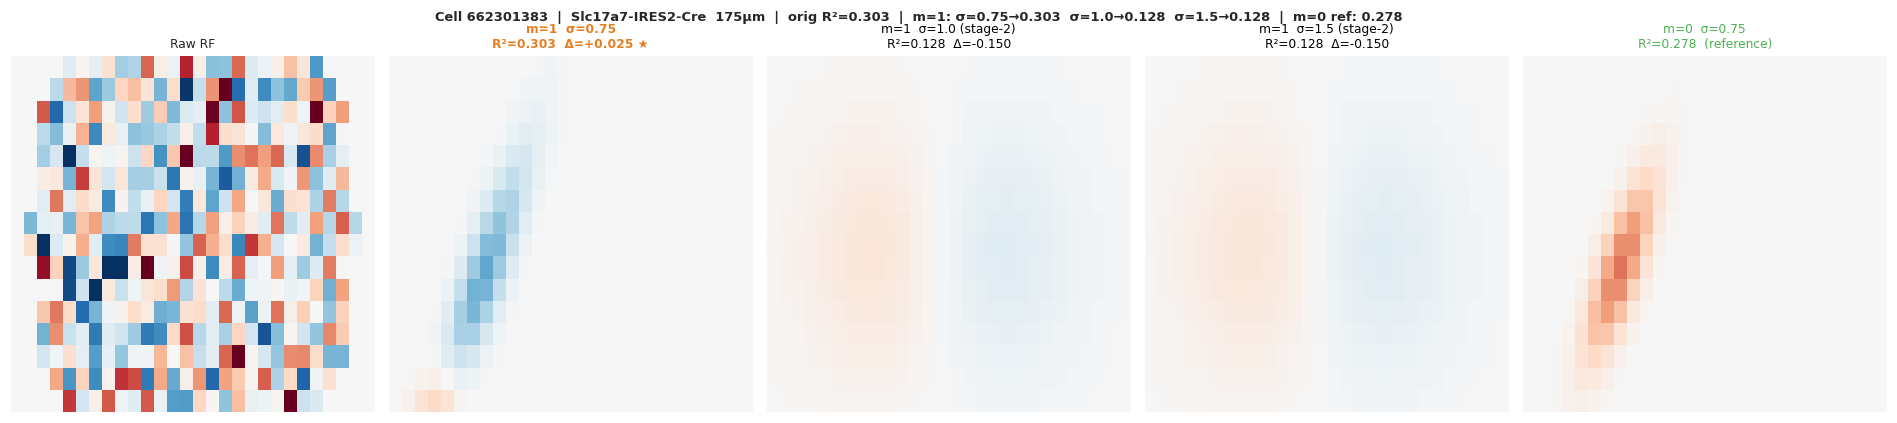

In [138]:
# ---------------------------------------------------------------------------
# SHOW CELL — re-run to advance to next neuron
# ---------------------------------------------------------------------------
row     = review_df.iloc[SMOOTH_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]

print(f'--- {SMOOTH_IDX+1}/{len(review_df)} ---  cell {cid}  '
      f'R²={row["r_squared"]:.3f}  ΔR²_vs_m0={row["delta_r2_vs_m0"]:.3f}')

if cid in smooth_judged_ids:
    prev = smooth_judged[smooth_judged['cell_id'] == cid].iloc[-1]
    print(f'↩ Previously: m={prev["m_final"]}  note="{prev["note"]}"')

_sigma_results = run_sigma_comparison(rf_map, pix, seed=cid)

r2s   = {s: _sigma_results[s][1][1]['r_squared'] for s in [0.75, 1.0, 1.5]}
r2_m0 = _sigma_results[0.75][0][1]['r_squared']
_best_sigma = max([0.75, 1.0, 1.5],
                   key=lambda s: r2s[s] if not np.isnan(r2s[s]) else -np.inf)

print(f'  σ=0.75: R²={r2s[0.75]:.3f}   σ=1.0: R²={r2s[1.0]:.3f}   '
      f'σ=1.5: R²={r2s[1.5]:.3f}   m=0 ref: R²={r2_m0:.3f}')
print(f'  Best sigma={_best_sigma}  ΔR²={r2s[_best_sigma]-r2_m0:+.3f}')

# Default: keep m=1 if ANY sigma gives ΔR²>0.05 over m=0
_smooth_best = 1 if any((r2s[s] - r2_m0) > 0.05
                         for s in [0.75, 1.0, 1.5]) else 0
print(f'Default: M_FINAL={_smooth_best}  '
      f'(1 if any sigma gives ΔR²>0.05; change in RECORD cell if you disagree)')

fig = plot_sigma_comparison(cid, rf_map, _sigma_results, row.to_dict())
plt.tight_layout()
plt.show()

In [139]:
# ---------------------------------------------------------------------------
# RECORD CELL — set M_FINAL then run, then re-run SHOW CELL
# ---------------------------------------------------------------------------
M_FINAL = 0  # ← change to 0 or 1 if you disagree with the default
NOTE    = ''             # ← optional free text

row = review_df.iloc[SMOOTH_IDX]
cid = int(row['cell_id'])

new_row       = pd.DataFrame([{'cell_id': cid, 'm_final': M_FINAL, 'note': NOTE}])
smooth_judged = pd.concat(
    [smooth_judged[smooth_judged['cell_id'] != cid], new_row],
    ignore_index=True
)
smooth_judged_ids = set(smooth_judged['cell_id'].tolist())
smooth_judged.to_csv(JUDGEMENT_CSV, index=False)

print(f'✓ Saved  cell {cid}  m={M_FINAL}  '
      f'({len(smooth_judged_ids)}/{len(review_df)} done, '
      f'{len(review_df)-len(smooth_judged_ids)} remaining)')

SMOOTH_IDX = _first_unjudged_smooth(SMOOTH_IDX + 1)
print(f'Next: index {SMOOTH_IDX}  →  re-run SHOW CELL')

✓ Saved  cell 662301383  m=0  (63/63 done, 0 remaining)
Next: index 62  →  re-run SHOW CELL


In [140]:
# ---------------------------------------------------------------------------
# MERGE CELL — run after completing review to update m_final in all_df
# and resave the combined CSV
# ---------------------------------------------------------------------------
smooth_judged = pd.read_csv(JUDGEMENT_CSV)

smooth_lookup = dict(zip(smooth_judged['cell_id'].astype(int),
                         smooth_judged['m_final'].astype(int)))
updated = 0
for cid, m_new in smooth_lookup.items():
    mask = all_df['cell_id'] == cid
    if mask.any():
        all_df.loc[mask, 'm_final'] = m_new
        updated += 1

m1_final = all_df[all_df['m_final'] == 1]
print(f'Updated {updated} neurons from smoothing review')
print(f'\nFinal m_final breakdown:')
print(all_df['m_final'].value_counts().sort_index())
print(f'\nFinal m=1: {len(m1_final)}')
print(f'  σ, κ summary:')
print(m1_final[['sigma', 'kappa', 'r_squared']].describe().round(3))

out = nb05d_dir / 'rf_params_order_v2_all_containers.csv'
all_df.to_csv(out, index=False)
print(f'\nSaved updated population → {out}')

Updated 63 neurons from smoothing review

Final m_final breakdown:
0    878
1     35
2    104
Name: m_final, dtype: int64

Final m=1: 35
  σ, κ summary:
        sigma   kappa  r_squared
count  35.000  35.000     35.000
mean    8.953   1.721      0.515
std     2.759   0.730      0.085
min     5.929   1.027      0.349
25%     7.425   1.254      0.467
50%     8.056   1.419      0.515
75%     9.047   1.965      0.552
max    17.027   3.733      0.723

Saved updated population → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/order_full_v2/rf_params_order_v2_all_containers.csv


In [141]:
# ---------------------------------------------------------------------------
# M=2 TRIAGE — append after 05e review is complete
# ---------------------------------------------------------------------------
JUDGEMENT_CSV_M2   = nb05d_dir / 'm2_review_judgements.csv'
AUTO_ACCEPT_THRESH = 0.10
AUTO_REJECT_THRESH = 0.05

m2_df       = all_df[all_df['m_final'] == 2].copy()
auto_accept = m2_df[m2_df['delta_r2_vs_m0'] >  AUTO_ACCEPT_THRESH]
auto_reject = m2_df[m2_df['delta_r2_vs_m0'] <  AUTO_REJECT_THRESH]
manual_q    = m2_df[
    (m2_df['delta_r2_vs_m0'] >= AUTO_REJECT_THRESH) &
    (m2_df['delta_r2_vs_m0'] <= AUTO_ACCEPT_THRESH)
].sort_values('delta_r2_vs_m0', ascending=False).reset_index(drop=True)

print(f'Total m=2: {len(m2_df)}')
print(f'  Auto-accept m=2  (ΔR² > {AUTO_ACCEPT_THRESH:.0%}): {len(auto_accept)}')
print(f'  Manual review    ({AUTO_REJECT_THRESH:.0%}–{AUTO_ACCEPT_THRESH:.0%}): {len(manual_q)}')
print(f'  Auto-reject m=0  (ΔR² < {AUTO_REJECT_THRESH:.0%}): {len(auto_reject)}')

Total m=2: 104
  Auto-accept m=2  (ΔR² > 10%): 0
  Manual review    (5%–10%): 2
  Auto-reject m=0  (ΔR² < 5%): 102


In [142]:
# Load any containers not already cached from 05e
by_container_m2 = manual_q.groupby('container_id')['cell_id'].apply(list).to_dict()
for container_id, cids in by_container_m2.items():
    missing = [c for c in cids if c not in rf_map_cache]
    if not missing:
        continue
    if container_id not in container_to_exp:
        print(f'{container_id}: not in session_c — skip'); continue
    try:
        if container_id not in dataset_cache:
            dataset_cache[container_id] = boc.get_ophys_experiment_data(
                container_to_exp[container_id])
        rf_map_cache.update(
            batch_get_rf_maps_safe(dataset_cache[container_id], missing))
        print(f'{container_id}: {len(missing)} loaded')
    except Exception as e:
        print(f'{container_id}: FAIL — {e}')

review_df_m2 = manual_q[manual_q['cell_id'].isin(rf_map_cache)].reset_index(drop=True)
print(f'{len(review_df_m2)} neurons ready for manual review')

# Init judgement store + pre-populate autos
if JUDGEMENT_CSV_M2.exists():
    m2_judged     = pd.read_csv(JUDGEMENT_CSV_M2)
    m2_judged_ids = set(m2_judged['cell_id'].tolist())
else:
    m2_judged     = pd.DataFrame(columns=['cell_id', 'm_final', 'note'])
    m2_judged_ids = set()

auto_rows = (
    [{'cell_id': int(r['cell_id']), 'm_final': 2,
      'note': f'auto-accept delta_r2={r["delta_r2_vs_m0"]:.3f}'}
     for _, r in auto_accept.iterrows() if int(r['cell_id']) not in m2_judged_ids] +
    [{'cell_id': int(r['cell_id']), 'm_final': 0,
      'note': f'auto-reject delta_r2={r["delta_r2_vs_m0"]:.3f}'}
     for _, r in auto_reject.iterrows() if int(r['cell_id']) not in m2_judged_ids]
)
if auto_rows:
    m2_judged     = pd.concat([m2_judged, pd.DataFrame(auto_rows)], ignore_index=True)
    m2_judged_ids = set(m2_judged['cell_id'].tolist())
    m2_judged.to_csv(JUDGEMENT_CSV_M2, index=False)
    print(f'Pre-populated {len(auto_rows)} auto decisions')

def _first_unjudged_m2(start=0):
    for i in range(start, len(review_df_m2)):
        if int(review_df_m2.iloc[i]['cell_id']) not in m2_judged_ids:
            return i
    return len(review_df_m2) - 1

M2_IDX = _first_unjudged_m2()
print(f'Remaining: {len(review_df_m2) - len(m2_judged_ids & set(review_df_m2["cell_id"]))}  |  Starting at: {M2_IDX}')

511509529: 1 loaded
688678764: 1 loaded
2 neurons ready for manual review
Pre-populated 102 auto decisions
Remaining: 2  |  Starting at: 0


--- 2/2 ---  cell 701720672  ΔR²=0.080
  m=2: σ=0.75→0.519  σ=1.0→0.519  σ=1.5→0.519
  m=0 ref: 0.440  |  ΔR²(σ=0.75): +0.080  |  Default: m=0
  [σ=1.0 and σ=1.5 shown for visual structure only — decision is σ=0.75]


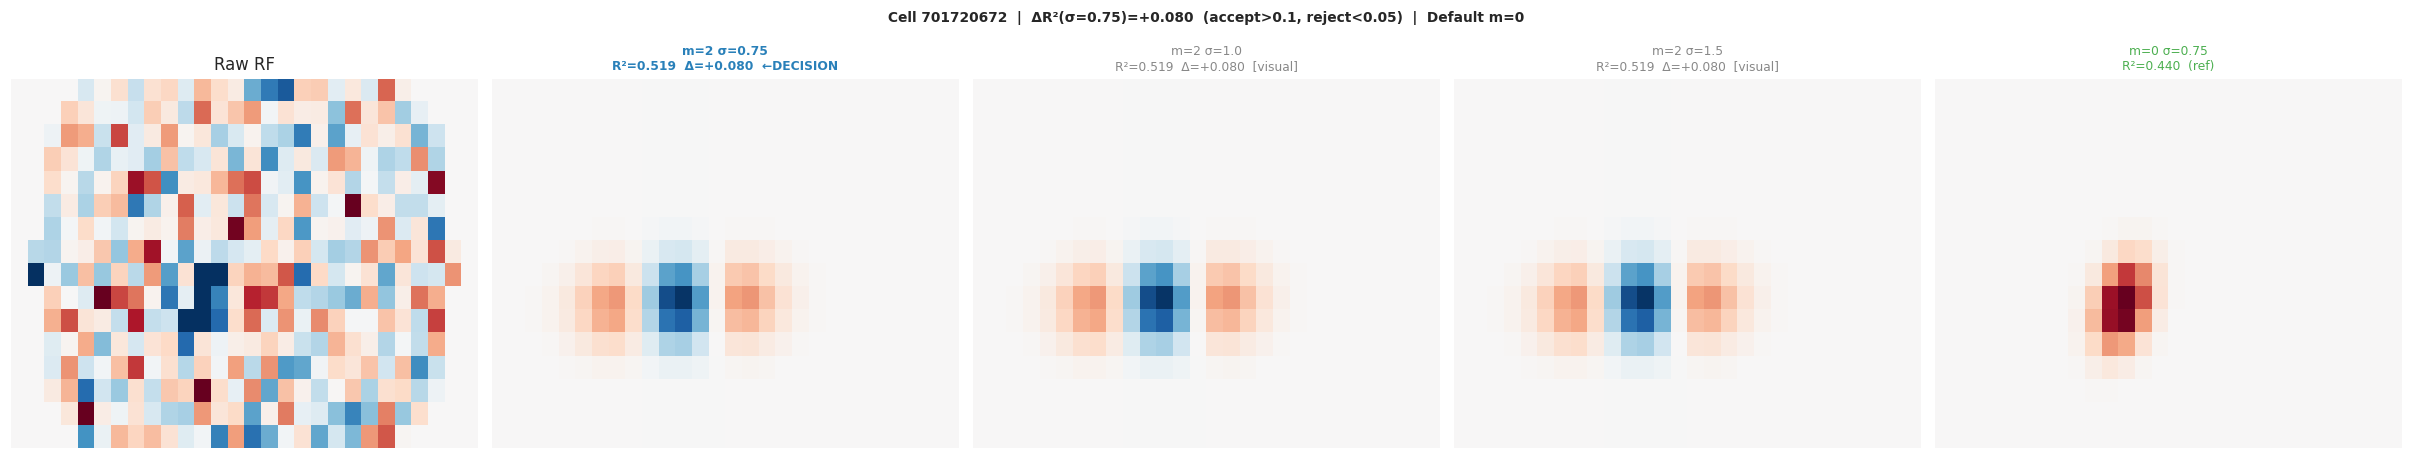

In [145]:
# SHOW CELL (m=2) — re-run to advance
row     = review_df_m2.iloc[M2_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]

print(f'--- {M2_IDX+1}/{len(review_df_m2)} ---  cell {cid}  ΔR²={row["delta_r2_vs_m0"]:.3f}')

# Reuse fit_with_sigma from 05e, just pass m=2 and m=0
_res = {}
rng  = np.random.default_rng(cid)
for sigma in [0.75, 1.0, 1.5]:
    _res[sigma] = {}
    for m in [0, 2]:
        s = int(rng.integers(0, 2**31))
        try:    _res[sigma][m] = fit_with_sigma(rf_map, pix, sigma, m=m, seed=s)
        except: _res[sigma][m] = (None, {'r_squared': np.nan}, None)

r2_m2  = {s: _res[s][2][1]['r_squared'] for s in [0.75, 1.0, 1.5]}
r2_m0  = _res[0.75][0][1]['r_squared']
delta  = r2_m2[0.75] - r2_m0
_m2_default = 2 if delta > AUTO_ACCEPT_THRESH else 0

print(f'  m=2: σ=0.75→{r2_m2[0.75]:.3f}  σ=1.0→{r2_m2[1.0]:.3f}  σ=1.5→{r2_m2[1.5]:.3f}')
print(f'  m=0 ref: {r2_m0:.3f}  |  ΔR²(σ=0.75): {delta:+.3f}  |  Default: m={_m2_default}')
print('  [σ=1.0 and σ=1.5 shown for visual structure only — decision is σ=0.75]')

# Plot: Raw | m=2 σ=0.75 [DECISION] | m=2 σ=1.0 | m=2 σ=1.5 | m=0 ref
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
vmax = np.nanpercentile(np.abs(rf_map), 98)
imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto',
            origin='lower', interpolation='nearest')
fig.suptitle(f'Cell {cid}  |  ΔR²(σ=0.75)={delta:+.3f}  '
             f'(accept>{AUTO_ACCEPT_THRESH}, reject<{AUTO_REJECT_THRESH})  '
             f'|  Default m={_m2_default}', fontsize=9, fontweight='bold')

axes[0].imshow(rf_map, **imkw); axes[0].set_title('Raw RF'); axes[0].axis('off')

for i, sigma in enumerate([0.75, 1.0, 1.5], 1):
    _, _, fitted = _res[sigma][2]
    if fitted is not None: axes[i].imshow(fitted, **imkw)
    else: axes[i].set_facecolor('#333')
    is_dec = (sigma == 0.75)
    axes[i].set_title(
        f'm=2 σ={sigma}\nR²={r2_m2[sigma]:.3f}  Δ={r2_m2[sigma]-r2_m0:+.3f}'
        + ('  ←DECISION' if is_dec else '  [visual]'),
        fontsize=8, fontweight='bold' if is_dec else 'normal',
        color='#2980b9' if is_dec else '#888')
    axes[i].axis('off')

_, _, f0 = _res[0.75][0]
if f0 is not None: axes[4].imshow(f0, **imkw)
axes[4].set_title(f'm=0 σ=0.75\nR²={r2_m0:.3f}  (ref)', fontsize=8, color='#4CAF50')
axes[4].axis('off')
plt.tight_layout(); plt.show()

In [146]:
# RECORD CELL (m=2)
M_FINAL = _m2_default  # <- override to 0 or 2
NOTE    = ''

cid = int(review_df_m2.iloc[M2_IDX]['cell_id'])
m2_judged     = pd.concat(
    [m2_judged[m2_judged['cell_id'] != cid],
     pd.DataFrame([{'cell_id': cid, 'm_final': M_FINAL, 'note': NOTE}])],
    ignore_index=True)
m2_judged_ids = set(m2_judged['cell_id'].tolist())
m2_judged.to_csv(JUDGEMENT_CSV_M2, index=False)

done = sum(c in m2_judged_ids for c in review_df_m2['cell_id'])
print(f'✓ cell {cid}  m={M_FINAL}  ({done}/{len(review_df_m2)} manual done)')
M2_IDX = _first_unjudged_m2(M2_IDX + 1)
print(f'Next: {M2_IDX}  → re-run SHOW CELL')

✓ cell 701720672  m=0  (2/2 manual done)
Next: 1  → re-run SHOW CELL
